In [1]:
import pandas as pd
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import ast
import re
import numpy as np
from scipy.stats import f_oneway
import statsmodels.api as sm
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from scipy.stats import ttest_ind

In [2]:
data = pd.read_csv('LDA topics.csv')
# 將整個欄位轉回 list 物件
data['terms'] = data['terms'].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)
# data['log_max_salary'] = np.log1p(data['max_salary'])  # 加1避免log(0)

# 薪資正規化
data['max_salary_K'] = data['max_salary'] / 1000
data['min_salary_K'] = data['min_salary'] / 1000

In [3]:
data.columns

Index(['jobType', 'jobNo', 'jobName', 'jobRole', 'jobRo', 'jobAddrNoDesc',
       'jobAddress', 'descWithoutHighlight', 'optionEdu', 'period',
       'periodDesc', 'applyCnt', 'applyType', 'applyDesc', 'custNo',
       'custName', 'coIndustry', 'coIndustryDesc', 'salaryDesc', 'landmark',
       'jobsource', 'lon', 'lat', 'remoteWorkType', 'major', 'salaryType',
       'dist', 'mrt', 'mrtDesc', 'query', 'min_salary', 'max_salary',
       'emp_desc', 'emp_param', 'zone_desc', 'zoneForeign_desc', 'remote_desc',
       'employees', 'job_category', 'major_資訊工程相關', 'major_資訊管理相關',
       'major_電機電子工程相關', 'major_數學及電算機科學學科類', 'major_數理統計相關',
       'major_其他數學及電算機科學相關', 'major_統計學相關', 'major_商業及管理學科類', 'major_工程學科類',
       'major_應用數學相關', 'major_財稅金融相關', 'major_工業工程相關', 'major_一般商業學類',
       'major_會計學相關', 'major_機械工程相關', 'text_normalized', 'terms', 'topic_id',
       'topic_name', 'topic_job', 'topic_job_category', 'max_salary_K',
       'min_salary_K'],
      dtype='object')

## 1. 各職缺類型占比

In [4]:
df = pd.DataFrame(data.groupby('topic_job_category')['jobNo'].size()).sort_values(by='jobNo')
df

,jobNo
topic_job_category,
BA,177
DS,261
DE,408
DA,463
ML,645


In [5]:
font_path = "C:/Windows/Fonts/msjh.ttc"
plt.rcParams['font.sans-serif'] = ['Microsoft JhengHei']  # 微軟正黑體
plt.rcParams['axes.unicode_minus'] = False  # 正負號也要支援中文

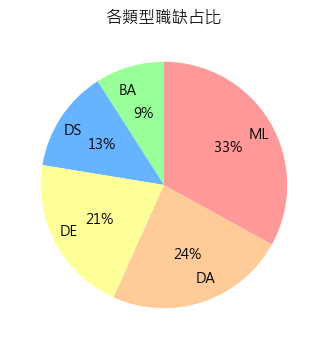

In [6]:
colors = ['#99ff99','#66b3ff', '#ffff99','#ffcc99', '#ff9999']
plt.figure(figsize=(6,4))
plt.pie(df['jobNo'], labels=df.index, autopct='%1.0f%%', startangle=90, colors=colors, labeldistance = 0.8)
plt.title('各類型職缺占比')
plt.show()

### 1.1 各類型職缺薪資比較

In [7]:
salary_data = data[(data['max_salary'] > 0)&(data['max_salary'] < 500000)&(data['salaryType'] != 'H')&(data['salaryType'] != 'D')].copy()

In [8]:
len(salary_data)

349

In [9]:
salary_group = data[(data['max_salary'] > 0)&(data['max_salary'] < 500000)&(data['salaryType'] != 'H')&(data['salaryType'] != 'D')].groupby(by=['topic_job_category']).agg({
        'jobNo': 'size',
        'min_salary': 'mean',
        'max_salary': 'mean'
    }).sort_values(by='min_salary', ascending=False)
salary_group

,jobNo,min_salary,max_salary
topic_job_category,,,
DS,38,68724.710526,113304.500000
BA,14,53704.761905,79026.190476
ML,107,53104.619938,89245.514019
DE,85,45975.019608,74387.427451
DA,105,41990.095238,61811.079365


In [10]:
groups = [salary_data[salary_data['topic_job_category'] == idx]['min_salary_K'] for idx, df in salary_group.iterrows()]

f_stats, p_vals = f_oneway(*groups)
print(f'F統計量: {f_stats:.2f}')
print(f'p-value: {p_vals:.4f}')

F統計量: 12.25
p-value: 0.0000


In [11]:
tukey = pairwise_tukeyhsd(endog=salary_data['min_salary_K'], groups=salary_data['topic_job_category'], alpha=0.05)
print(tukey)

 Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower    upper  reject
-----------------------------------------------------
    BA     DA -11.7147 0.3111 -28.4873   5.058  False
    BA     DE  -7.7297 0.7239 -24.7329  9.2734  False
    BA     DS  15.0199 0.1694  -3.4103 33.4502  False
    BA     ML  -0.6001    1.0 -17.3543  16.154  False
    DA     DE   3.9849 0.7095  -4.6163 12.5861  False
    DA     DS  26.7346    0.0  15.5745 37.8947   True
    DA     ML  11.1145 0.0018   3.0167 19.2123   True
    DE     DS  22.7497    0.0   11.246 34.2534   True
    DE     ML   7.1296  0.153  -1.4356 15.6948  False
    DS     ML -15.6201 0.0013 -26.7524 -4.4877   True
-----------------------------------------------------


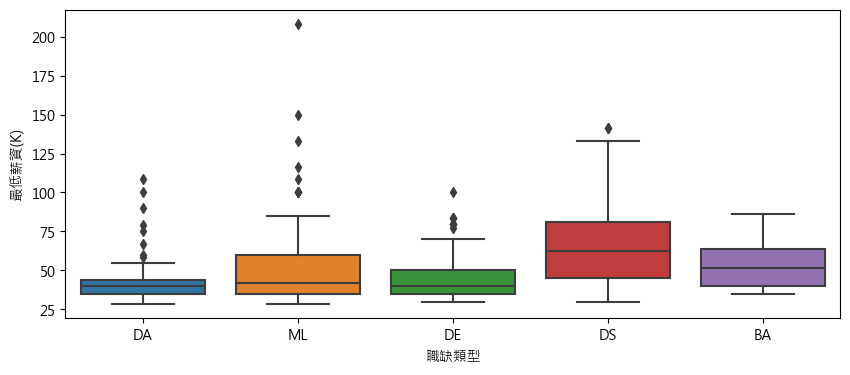

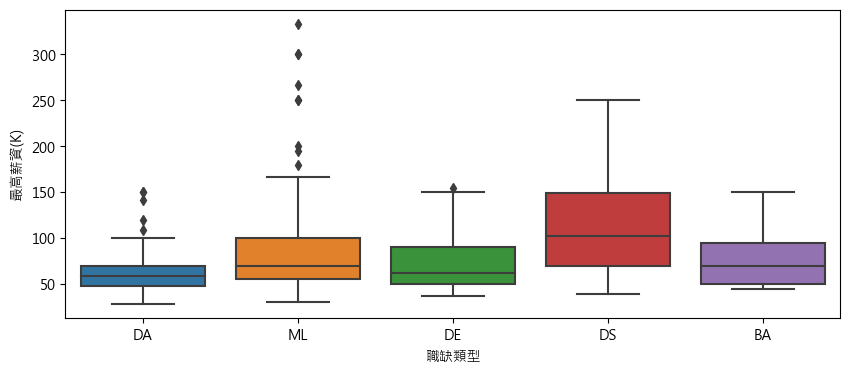

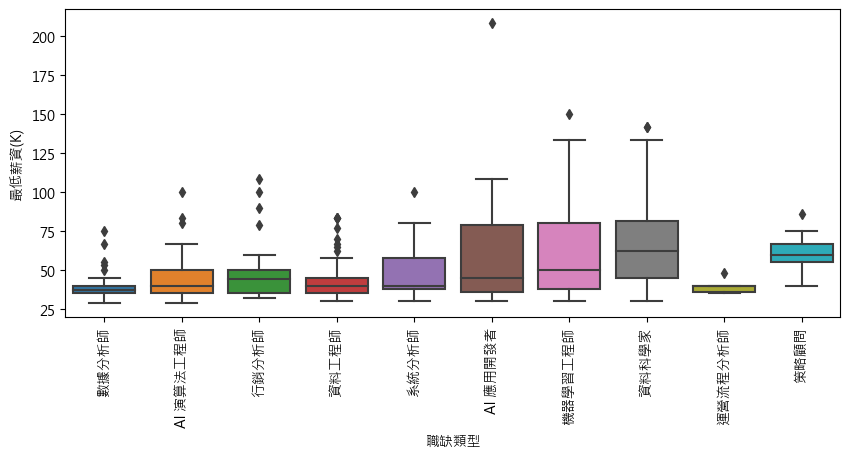

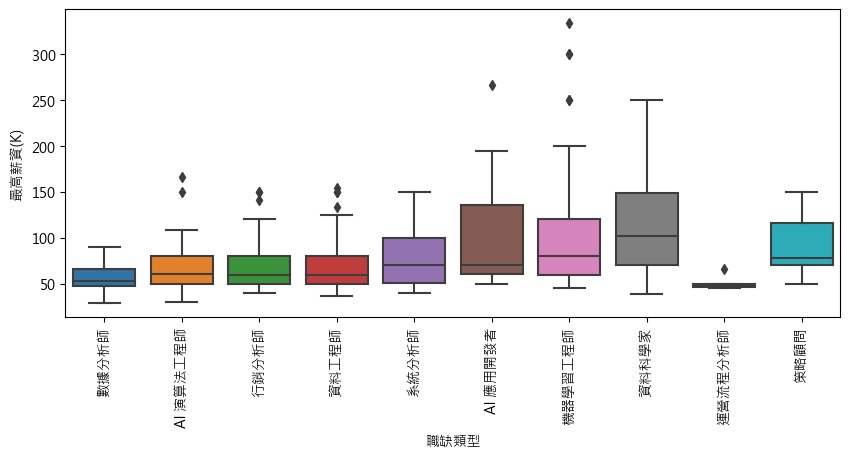

In [12]:
plt.figure(figsize=(10,4))
sns.boxplot(x='topic_job_category', y='min_salary_K', data=salary_data)
plt.xlabel('職缺類型')
plt.ylabel('最低薪資(K)')
plt.show()

plt.figure(figsize=(10,4))
sns.boxplot(x='topic_job_category', y='max_salary_K', data=salary_data)
plt.xlabel('職缺類型')
plt.ylabel('最高薪資(K)')
plt.show()

plt.figure(figsize=(10,4))
sns.boxplot(x='topic_job', y='min_salary_K', data=salary_data)
plt.xlabel('職缺類型')
plt.ylabel('最低薪資(K)')
plt.xticks(rotation=90)
plt.show()

plt.figure(figsize=(10,4))
sns.boxplot(x='topic_job', y='max_salary_K', data=salary_data)
plt.xlabel('職缺類型')
plt.ylabel('最高薪資(K)')
plt.xticks(rotation=90)
plt.show()

<Figure size 600x400 with 0 Axes>

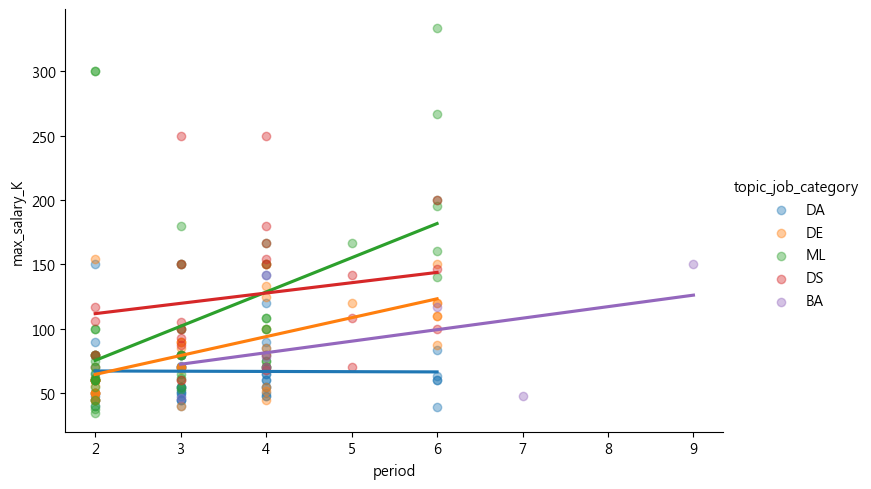

In [13]:
plt.figure(figsize=(6,4))
sns.lmplot(
    data=salary_data[salary_data['period']>0], #排除經驗不拘
    x='period',
    y='max_salary_K',
    hue='topic_job_category',
    aspect=1.5,
#     height=6,
    scatter_kws={'alpha':0.4},
    ci=None
)
plt.show()

<Figure size 600x400 with 0 Axes>

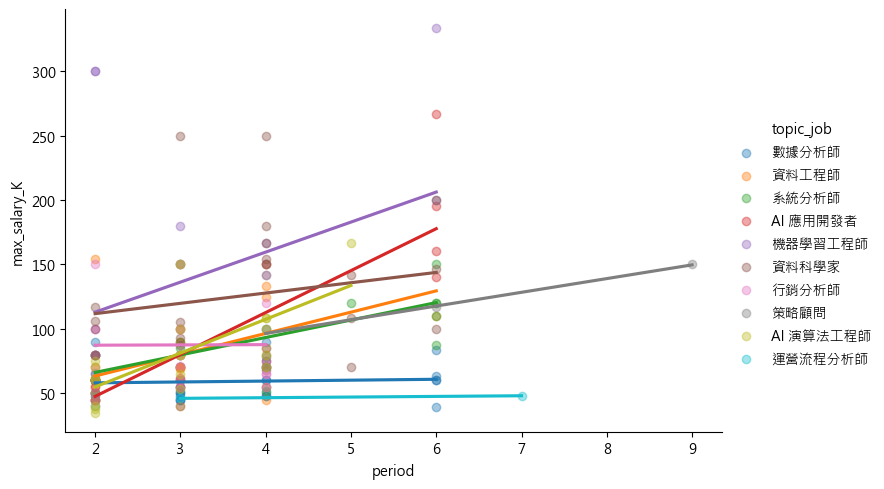

In [14]:
plt.figure(figsize=(6,4))
sns.lmplot(
    data=salary_data[salary_data['period']>0], #排除經驗不拘
    x='period',
    y='max_salary_K',
    hue='topic_job',
    aspect=1.5,
#     height=6,
    scatter_kws={'alpha':0.4},
    ci=None
)
plt.show()

In [15]:
salary_data[['period', 'periodDesc']].drop_duplicates()

,period,periodDesc
4,0,經歷不拘
9,3,2年以上
13,2,1年以上
28,4,3年以上
36,5,4年以上
197,6,5年以上
623,7,6年以上
898,9,8年以上


In [16]:
salary_group = salary_data.groupby(by=['topic_job']).agg({
        'jobNo': 'size',
        'min_salary': 'mean',
        'max_salary': 'mean'
    }).sort_values(by='min_salary', ascending=False)
salary_group

,jobNo,min_salary,max_salary
topic_job,,,
資料科學家,38,68724.710526,113304.500000
AI 應用開發者,18,62870.370370,101037.037037
策略顧問,9,61429.629630,94596.296296
機器學習工程師,37,60312.864865,113297.027027
系統分析師,31,49390.322581,80745.161290
行銷分析師,37,48022.522523,70540.540541
AI 演算法工程師,52,44595.224359,68050.256410
資料工程師,54,44014.382716,70737.617284
運營流程分析師,5,39800.000000,51000.000000


In [17]:
groups = [salary_data[salary_data['topic_job'] == idx]['max_salary_K'] for idx, df in salary_group.iterrows()]

f_stats, p_vals = f_oneway(*groups)
print(f'F統計量: {f_stats:.2f}')
print(f'p-value: {p_vals:.4f}')

F統計量: 9.64
p-value: 0.0000


In [18]:
tukey = pairwise_tukeyhsd(endog=salary_data['max_salary_K'], groups=salary_data['topic_job'], alpha=0.05)
print(tukey)

     Multiple Comparison of Means - Tukey HSD, FWER=0.05     
  group1    group2  meandiff p-adj    lower    upper   reject
-------------------------------------------------------------
 AI 應用開發者 AI 演算法工程師 -32.9868 0.1047  -68.9957   3.0221  False
 AI 應用開發者     數據分析師 -43.9758 0.0029  -78.8783  -9.0733   True
 AI 應用開發者   機器學習工程師    12.26 0.9901  -25.5793  50.0992  False
 AI 應用開發者      策略顧問  -6.4407    1.0  -60.1962  47.3147  False
 AI 應用開發者     系統分析師 -20.2919 0.8189  -59.3112  18.7274  False
 AI 應用開發者     行銷分析師 -30.4965 0.2377  -68.3358   7.3428  False
 AI 應用開發者     資料工程師 -30.2994 0.1808  -66.1364   5.5376  False
 AI 應用開發者     資料科學家  12.2675 0.9898  -25.4085  49.9434  False
 AI 應用開發者   運營流程分析師  -50.037 0.3326 -116.6013  16.5272  False
AI 演算法工程師     數據分析師  -10.989 0.9127  -35.2458  13.2677  False
AI 演算法工程師   機器學習工程師  45.2468    0.0   16.9269  73.5666   True
AI 演算法工程師      策略顧問   26.546 0.7484  -20.9919   74.084  False
AI 演算法工程師     系統分析師  12.6949 0.9401  -17.1833  42.5731  False
AI 演算法工程

## 2. 薪資分析
### 2.1 技能 v.s. 薪資

In [68]:
skills = {
    'martech': ['行銷科技', 'ga4', 'gtm', '搜尋引擎最佳化','ahref','搜尋引擎行銷'],
    '統計': ['統計'],
    '視覺化': ['可視化','視覺化'],
    '報表': ['報表', '指標','儀表板','Tableau'],
    '分析': ['分析', '數據分析','商業分析'],
    'llm': ['llm', '自然語言處理','生成式ai','langchain'],
    '深度學習': ['深度學習', 'tensorflow','pytorch'],
    '演算法': ['演算法'],
    '機器學習 ai': ['機器學習', '預測','模型', '趨勢', '模型訓練','訓練模型','預測模型', 'ai'],
    '溝通': ['溝通', '跨部門', '合作','跨部門合作'],
    '分析報告': ['分析報告', '報告'],
    '專案': ['專案', '管理'],
    'Python': ['numpi','Python', 'panda'],
    '策略': ['策略', '決策'],
    '資料庫': ['資料庫','數據庫'],
    'ETL': ['ETL', '數據工程','數據管道','數據流'],
    '商業智慧': ['商業智慧'],
    '爬蟲': ['爬蟲','selenium'],
    '影像處理': ['影像辨識','影像處理', '影像'],
    '資料倉儲': ['資料倉儲', '倉儲', '數據湖'],
    'git': ['git', '版本控制'],
    '資料探勘': ['資料探勘'],
    'SQL': ['mysql', 'mongodb','postgresql','nosql'],
    '特徵工程' : ['資料清洗', '前處理', '特徵工程', '清洗'],
    'docker': ['docker'],
    '機器人': ['機器人'],
    'airflow': ['airflow'],
    'hadoop': ['hadoop'],
    '客戶分群': ['客戶分群','分群'],
    'gcp': ['gcp','bigqueri', 'looker', 'looker studio'],
    '解決問題': ['解決問題', '解決方案'],
    '顧客關係管理': ['顧客關係管理','行為分析', '旅程'],
    'web 開發': ['django', 'javascript','css'],
    '流程自動化': ['流程自動化', '自動化'],
    '數據治理': ['數據治理']
}
skill_groups = {
    'skill_data_eng': [
        'term_ETL', 'term_資料倉儲', 'term_airflow', 'term_hadoop',  'term_docker', 'term_數據治理'
    ],
    'skill_analytics': [
        'term_統計', 'term_分析', 'term_分析報告'
    ],
    'skill_solve_problem': [
        'term_解決問題', 'term_流程自動化'
    ],
    'skill_visual': [
        'term_報表', 'term_視覺化'
    ],
    'skill_ai_ml': [
        'term_機器學習 ai', 'term_演算法', 'term_深度學習',  'term_特徵工程'
    ],
    'skill_llm': [
        'term_llm'
    ],
    'skill_image_processing': [
        'term_影像處理'
    ],
    'skill_SQL_gcp': [
        'term_SQL', 'term_gcp'
    ],
    'skill_data_mining': [
        'term_資料探勘'
    ],
    'skill_scraper': [
        'term_爬蟲'
    ],
    'skill_web_develop': [
        'term_web 開發'
    ],
    'skill_codes': [
        'term_Python', 'term_git'
    ],
    'skill_martech': [
        'term_martech', 'term_顧客關係管理', 'term_客戶分群'
    ],
    'skill_business': [
        'term_策略', 'term_商業智慧'
    ],
    'skill_project_comm': [
        'term_專案', 'term_溝通'
    ],
    'skill_robot': [
        'term_機器人'
    ]
}



In [69]:
# 新增技能相關欄位
term_cols = []
for skill in skills.keys():
    col = 'term_'+skill
    salary_data[col] = 0 *len(salary_data)
    term_cols.append(col)
    
def skills_cols(df, i, terms):
    
    for skill in skills.items():
        category = 'term_'+skill[0]
        skill_list = skill[1]

        if len(set(terms)&set(skill_list))>0:
            df.loc[i, category] = 1


for i, df in salary_data.iterrows():
    skills_cols(salary_data, i, df['terms'])

In [70]:
skill_cols = list(skill_groups.keys())
for g in skill_groups.keys():
    salary_data[g] = salary_data[skill_groups[g]].sum(axis=1)

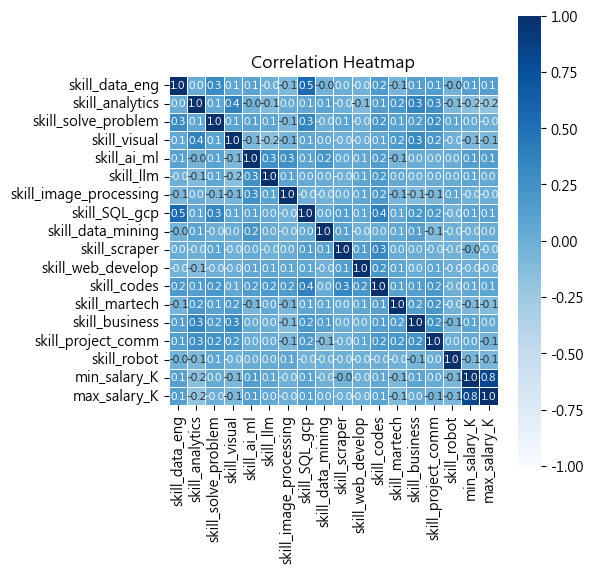

In [71]:
plt.figure(figsize=(6, 6))
sns.heatmap(
    salary_data[skill_cols + ['min_salary_K', 'max_salary_K']].corr(),
    annot=True,         # 顯示數字
    fmt=".1f",          # 顯示兩位小數
    cmap='Blues',    # 顏色範圍從藍到紅
    vmin=-1, vmax=1,    # 標準化顏色區間
    linewidths=0.5,
    square=True,
    annot_kws={"size": 8}
)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

In [72]:
X = salary_data[skill_cols]
X = sm.add_constant(X)
y = salary_data['max_salary_K']

model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:           max_salary_K   R-squared:                       0.106
Model:                            OLS   Adj. R-squared:                  0.063
Method:                 Least Squares   F-statistic:                     2.469
Date:                Fri, 11 Apr 2025   Prob (F-statistic):            0.00146
Time:                        11:26:03   Log-Likelihood:                -1809.2
No. Observations:                 349   AIC:                             3652.
Df Residuals:                     332   BIC:                             3718.
Df Model:                          16                                         
Covariance Type:            nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
const                     84

Text(0.5, 1.0, '技能對 max_salary 的影響（OLS 係數）')

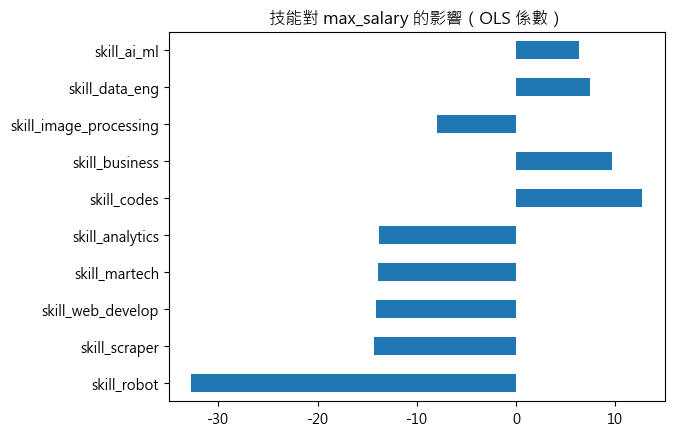

In [67]:
coefs = model.params.drop('const')
coefs[coefs.abs().sort_values(ascending=False).index].head(10).plot(kind='barh')
plt.title("技能對 max_salary 的影響（OLS 係數）")

#### 有沒有各技能對薪資的影響

In [55]:
t_test_results = []

for skill in skill_cols:
    groups = [salary_data[salary_data[skill]==1]['max_salary_K'], salary_data[salary_data[skill]==0]['max_salary_K']]
    
     # 若樣本數不足就跳過
    if len(groups[0]) < 10 or len(groups[1]) < 10:
        continue
        
     # 做 Welch's t-test（不假設變異數相等）
    t_stat, p_val = ttest_ind(groups[0], groups[1], equal_var=False)
    diff = groups[0].mean() - groups[1].mean()

    t_test_results.append({
        'skill': skill.replace('term_', ''),
        'mean_min_salary_with_skill': groups[0].mean(),
        'mean_min_salary_without_skill': groups[1].mean(),
        'mean_diff': diff,
        'p_value': p_val
    })

# 整理成 DataFrame 並排序
t_test_df = pd.DataFrame(t_test_results)
t_test_df = t_test_df.sort_values(by='p_value')



In [56]:
t_test_df

,skill,mean_min_salary_with_skill,mean_min_salary_without_skill,mean_diff,p_value
10,skill_martech,58.838095,81.005206,-22.167111,0.000018
1,skill_analytics,73.466045,90.870253,-17.404208,0.002356
0,skill_data_eng,92.560035,77.495640,15.064395,0.013085
13,skill_robot,69.363095,80.537924,-11.174829,0.029308
4,skill_ai_ml,81.439847,71.166072,10.273775,0.038583
8,skill_tools,87.705604,78.925394,8.780210,0.188722
3,skill_visual,74.751240,81.484464,-6.733224,0.219746
7,skill_fundamental,94.848485,79.085707,15.762778,0.249221
12,skill_project_comm,77.001488,81.949576,-4.948088,0.323668
2,skill_solve_problem,83.380523,79.132125,4.248398,0.501865


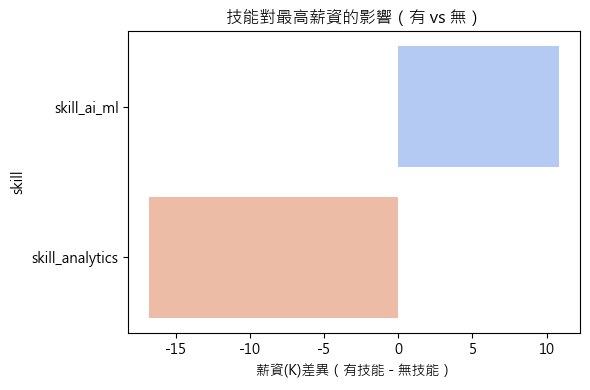

In [48]:
top_skills = t_test_df[t_test_df['p_value'] < 0.1].sort_values('mean_diff', ascending=False).head(10)

plt.figure(figsize=(6, 4))
sns.barplot(data=top_skills, x='mean_diff', y='skill', palette='coolwarm')
plt.title('技能對最高薪資的影響（有 vs 無）')
plt.xlabel('薪資(K)差異（有技能 - 無技能）')
plt.tight_layout()
plt.show()

### 2.2 BA/DA/DS 技能樹增值空間

In [28]:
analyst_data = salary_data[(salary_data['topic_job_category']=='BA')|((salary_data['topic_job_category']=='DA')|((salary_data['topic_job_category']=='DS')))].copy()

In [29]:
len(analyst_data)

157

In [30]:
t_test_results = []

for skill in term_cols:
    groups = [analyst_data[analyst_data[skill]==1]['min_salary_K'], analyst_data[analyst_data[skill]==0]['min_salary_K']]
    
     # 若樣本數不足就跳過
    if len(groups[0]) < 10 or len(groups[1]) < 10:
        continue
        
     # 做 Welch's t-test（不假設變異數相等）
    t_stat, p_val = ttest_ind(groups[0], groups[1], equal_var=False)
    diff = groups[0].mean() - groups[1].mean()

    t_test_results.append({
        'skill': skill.replace('term_', ''),
        'mean_min_salary_with_skill': groups[0].mean(),
        'mean_min_salary_without_skill': groups[1].mean(),
        'mean_diff': diff,
        'p_value': p_val
    })

# 整理成 DataFrame 並排序
t_test_df = pd.DataFrame(t_test_results)
t_test_df = t_test_df.sort_values(by='p_value')



In [31]:
t_test_df

,skill,mean_min_salary_with_skill,mean_min_salary_without_skill,mean_diff,p_value
7,分析報告,40.929697,50.903054,-9.973357,0.000985
5,機器學習 ai,56.227183,45.118740,11.108442,0.005022
1,視覺化,42.293103,51.139576,-8.846472,0.007694
3,分析,46.479101,58.068049,-11.588948,0.022078
9,Python,57.326923,47.953173,9.373750,0.074426
12,解決問題,59.306772,48.156065,11.150707,0.079759
4,演算法,60.850000,48.733780,12.116220,0.230306
10,策略,52.281987,48.130498,4.151489,0.249892
6,溝通,51.451852,48.723503,2.728349,0.492433
11,資料庫,51.275000,49.247195,2.027805,0.725881


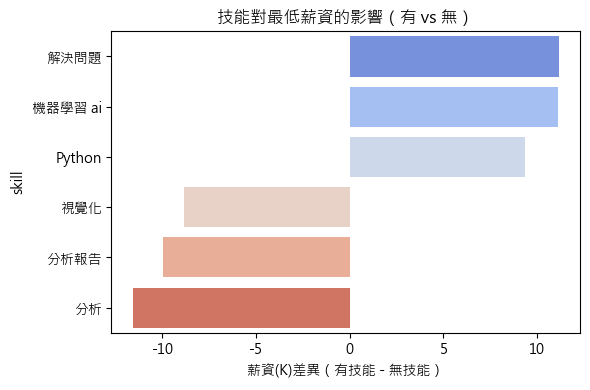

In [32]:
top_skills = t_test_df[t_test_df['p_value'] < 0.1].sort_values('mean_diff', ascending=False).head(10)

plt.figure(figsize=(6, 4))
sns.barplot(data=top_skills, x='mean_diff', y='skill', palette='coolwarm')
plt.title('技能對最低薪資的影響（有 vs 無）')
plt.xlabel('薪資(K)差異（有技能 - 無技能）')
plt.tight_layout()
plt.show()

In [33]:
X = analyst_data[term_cols]
X = sm.add_constant(X)
y = analyst_data['max_salary_K']

model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:           max_salary_K   R-squared:                       0.362
Model:                            OLS   Adj. R-squared:                  0.184
Method:                 Least Squares   F-statistic:                     2.036
Date:                Fri, 11 Apr 2025   Prob (F-statistic):            0.00260
Time:                        10:52:00   Log-Likelihood:                -769.44
No. Observations:                 157   AIC:                             1609.
Df Residuals:                     122   BIC:                             1716.
Df Model:                          34                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const           87.9783      6.638     13.253   

In [34]:
analyst_data.groupby('topic_job_category')['term_git', 'max_salary_K'].mean()

C:\Users\Police\AppData\Local\Temp\ipykernel_15920\3399350979.py:1: FutureWarning: Indexing with multiple keys (implicitly converted to a tuple of keys) will be deprecated, use a list instead.
  analyst_data.groupby('topic_job_category')['term_git', 'max_salary_K'].mean()


,term_git,max_salary_K
topic_job_category,,
BA,0.000000,79.026190
DA,0.009524,61.811079
DS,0.078947,113.304500


## 2.3.  Regression 分析(僅分析師類工作) - 主要技能 + 其他變數

In [35]:
analyst_data['employees'] = analyst_data['employees'].fillna(0)

In [36]:
analyst_data['is_remote'] = analyst_data['remote_desc'].apply(lambda x: 1 if x=='遠端工作' else 0)

In [37]:
def scale_company(num):
    
    if num <= 50:
        return 1
    if num <= 100:
        return 2
    if num <= 200:
        return 3
    if num <= 500:
        return 4
    return 5

analyst_data['company_scale'] = analyst_data['employees'].apply(lambda x: scale_company(x))

In [38]:
def label_encoding_education(x):
    
    if x == '高中以下':
        return 1
    if x == '專科':
        return 2
    if x == '高中':
        return 2
    if x == '大學':
        return 3
    if x == '碩士':
        return 4
    return 0


analyst_data['education'] = analyst_data['optionEdu'].apply(lambda x: label_encoding_education(x))

In [39]:
analyst_data['major_infomation'] = analyst_data['major_資訊工程相關']+ analyst_data['major_資訊管理相關']
analyst_data['major_engineer'] = analyst_data['major_電機電子工程相關'] + analyst_data['major_工程學科類']+ analyst_data['major_機械工程相關']
analyst_data['major_math_and_stats'] = analyst_data['major_數學及電算機科學學科類']+ analyst_data['major_數理統計相關']+ analyst_data['major_其他數學及電算機科學相關'] + analyst_data['major_應用數學相關'] + analyst_data['major_統計學相關']
analyst_data['major_commercial'] = analyst_data['major_商業及管理學科類'] + analyst_data['major_一般商業學類']

In [40]:
term_cols

['term_martech',
 'term_統計',
 'term_視覺化',
 'term_報表',
 'term_分析',
 'term_llm',
 'term_深度學習',
 'term_演算法',
 'term_機器學習 ai',
 'term_溝通',
 'term_分析報告',
 'term_專案',
 'term_Python',
 'term_策略',
 'term_資料庫',
 'term_ETL',
 'term_商業智慧',
 'term_爬蟲',
 'term_影像處理',
 'term_資料倉儲',
 'term_git',
 'term_資料探勘',
 'term_SQL',
 'term_特徵工程',
 'term_docker',
 'term_機器人',
 'term_airflow',
 'term_hadoop',
 'term_客戶分群',
 'term_gcp',
 'term_解決問題',
 'term_顧客關係管理',
 'term_web 開發',
 'term_流程自動化',
 'term_數據治理']

In [41]:
# analyst_data['skills_ML'] = analyst_data.apply(lambda x: 1 if x['term_演算法'] + x['term_機器學習 ai'] > 0 else 0)

In [42]:
x_cols = [
    'term_martech', 'term_視覺化','term_演算法', 'term_分析', 'term_機器學習 ai', 'term_分析報告',
    'term_Python', 'term_git', 'term_機器人', 'term_客戶分群', 'term_解決問題',
    'period', 'applyCnt', 'employees', 'is_remote', 'company_scale', 'education',
    'major_infomation', 'major_engineer', 'major_math_and_stats', 'major_commercial'
]

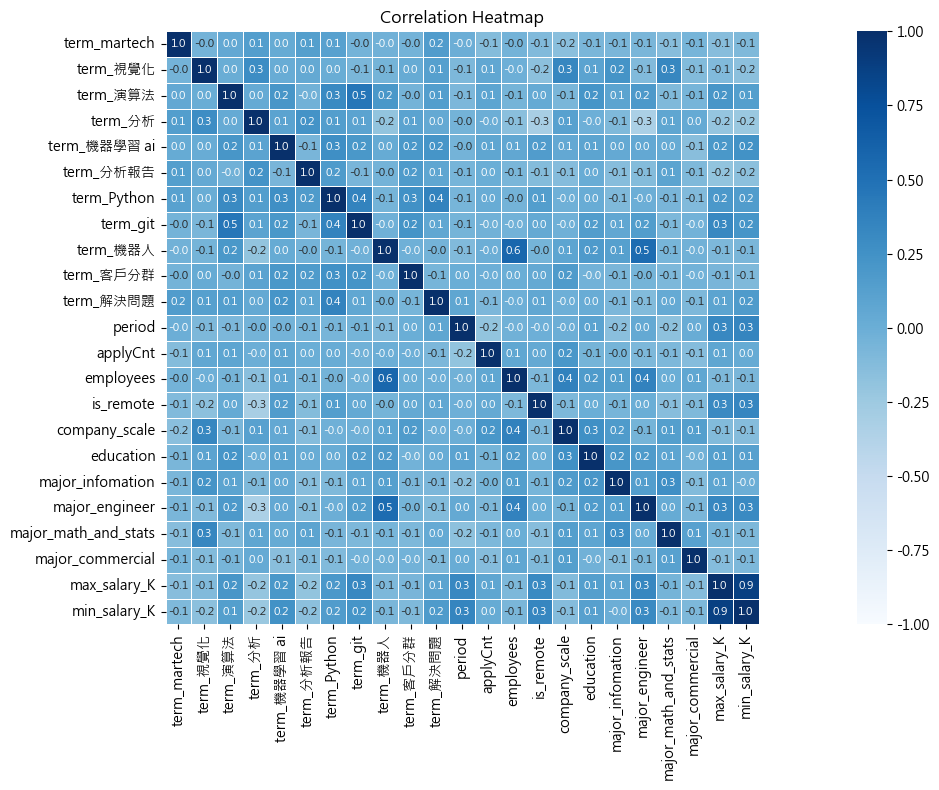

In [43]:
plt.figure(figsize=(20, 8))
sns.heatmap(
    analyst_data[x_cols+['max_salary_K', 'min_salary_K']].corr(),
    annot=True,         # 顯示數字
    fmt=".1f",          # 顯示兩位小數
    cmap='Blues',    # 顏色範圍從藍到紅
    vmin=-1, vmax=1,    # 標準化顏色區間
    linewidths=0.5,
    square=True,
    annot_kws={"size": 8}
)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

In [44]:
X = analyst_data[x_cols]
X = sm.add_constant(X)
y = analyst_data['max_salary_K']

model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:           max_salary_K   R-squared:                       0.536
Model:                            OLS   Adj. R-squared:                  0.463
Method:                 Least Squares   F-statistic:                     7.411
Date:                Fri, 11 Apr 2025   Prob (F-statistic):           4.26e-14
Time:                        11:00:07   Log-Likelihood:                -744.52
No. Observations:                 157   AIC:                             1533.
Df Residuals:                     135   BIC:                             1600.
Df Model:                          21                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                   42.7623 